# including code

In [1]:
pathtosrc="../src"; # adjust this to point to the "src" folder in the HHGsimPL.jl folder, wherever that might be saved on you computer

### for the PL Integration methods

In [5]:
include(pathtosrc*"/header/PLIntegration2D/PLIntegration2D.jl");

### external packages

In [3]:
using Sobol
using NLsolve
using QuadGK
using LinearAlgebra
using Integrals
using FiniteDiff
using StaticArrays
using Contour
using Peaks
using DataFrames

In [4]:
using GLMakie # for plotting

### my definitions of the setup

In [3]:
# include("../src/header/includes.jl"); # at some point I could put all the includes in here

In [8]:
include(pathtosrc*"/header/utils.jl")
include(pathtosrc*"/header/beams.jl");
include(pathtosrc*"/header/saddles.jl");
[include(pathtosrc*"/header/Beams/"*fn) for fn in readdir(pathtosrc*"/header/Beams/")]
include(pathtosrc*"/header/equations.jl");
include(pathtosrc*"/header/ionisationbursts.jl");
include(pathtosrc*"/header/harmonic-response.jl");

In [9]:
### just for convenience
function action_functions(b::Beam, Ip::Number, q::Number)
    
    action(ti, tr) = -im*S(b, Ip, ti, tr, q)
    action_grad(ti, tr) = -1im .* [dS_dti(b,Ip,q,ti,tr); dS_dtr(b,Ip,q,ti,tr)]
    action_hessian(ti,tr) = my_hessian(b, Ip, q, ti, tr)
    
    return action, action_grad, action_hessian
end

action_functions (generic function with 1 method)

# laser field definition

The "tunnelling-without-barrier" scenario (as in our paper) is just any field composed of the two frequencies $\omega$ and $2 \omega$, with equal intensities and $\pi/2$ phase shift between them.

In [6]:
Intensity0 = 1.5e14;
λ = 800;

In [10]:
beam_twob = BeamBETC(Intensity1 = Intensity0, Intensity2 = Intensity0, lambda=λ, r=1, s=2, epsilon = 0., phi = π/2)

BeamTC(0.06546536707079771, 0.06546536707079771, 0.056939529014612654, 0.11387905802922531, 0.0, 0.0, 1.5707963267948966)

### plotting the field shape

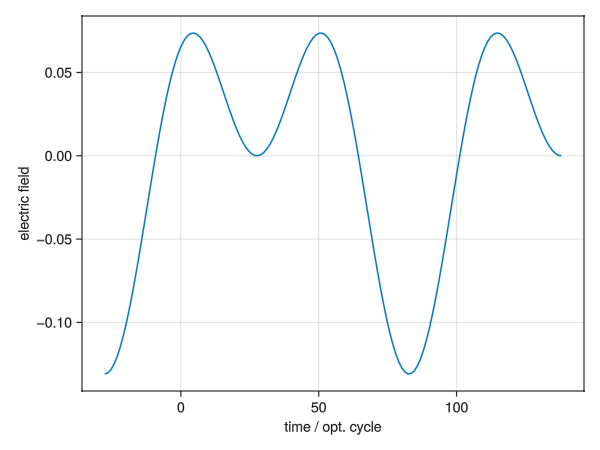

In [11]:
let # local scope block
   
    beam = beam_twob
    
    TC = TCycle(beam) # 1 optical cycle = 2π/ω
    times = range(-0.25TC, stop = 1.25*TC, length = 150)
    
    efield = [E(beam)(t)[1] for t in times]
    
    f = Figure()
    ax = Axis(f[1, 1],
        xlabel = "time / opt. cycle",
        ylabel = "electric field"
    ) 
    
    lines!(ax, times, efield)

    f
end

### convenience function to make different beams

<div class="alert alert-warning">
Note / To do: I guess you will want to create a function that returns a Beam struct for a given given intensity.
</div>

just as an example, if you were interested in how the HHG spectrum of a colinear two-colour field depends on the relative intensity of the two components, you could define yourself a function like this:

In [83]:
function beam_R(R::Number)
    ### ω-2ω, linearly polarised, no phase shift
    λ = 1030 # fundamental wavelength in nm
    I_total = 0.92e14;
    
    return BeamBETC(Intensity1 = I_total, Intensity2 = R/(1-R)*I_total,
        lambda=λ, r = 1, s = 2, epsilon = 0., phi = 0.)
end

beam_R (generic function with 1 method)

# target

This code is for hydrogenic targets only, and we're working within the SFA, so all we use to describe the target is its ionisation potential `Ip`, in atomic units.

In [24]:
const Ip = IpAU(15.7596) # Argon gas target, we will keep this constant

0.5791543250255408

In case you want to look at the classical solutions you can set $I_p = 0$.

In [14]:
const Ip_class = 0.0;

# preliminary considerations for the setup

### Keldysh parameter

<div class="alert alert-warning">
Note / To do: Check that the Keldysh parameter $\gamma$ for your setup is <1.
</div>

In [ ]:
# (... calculate the Keldysh parameter)

### Harmonic orders

minimal harmonic order should be (slightly above) the threshold harmonic:

In [21]:
Ip/get_omega(λ) # 1030 nm fundamental wavelength

10.171392968089176

maxmimal harmonic order can be easy 30% above the classical cutoff order:

In [19]:
(Ip + 3.17*get_Up(beam_twob))/get_omega(λ)

33.16943625971628

In [23]:
q_values = collect(11:50);

# classification code

## structs

In [11]:
struct ClassifiedSaddle
    s::Saddle
    tag::Int
    relevant::Bool
end

In [12]:
struct ClassifiedDipole
    q::Number
    dip::Vector{ComplexF64}
    tag::Int
    relevant::Bool
    int::Float64
end

## functions

### trace_saddle_across_q()

In [14]:
function trace_saddle_across_q(s::Saddle, qmin::Number, qmax::Number;
        b::Beam, Ip::Real, qstep::Number=1.,
        beam::Beam=b )
    
    ### now iterate to above
    s_init = s
    q_init = s.q
    saddles = [s_init] # better julia would be to define that array beforehand and then just fill it
    
    TC = TCycle(b)
    
    ### to above
    for q in range(q_init, stop = qmax, step = qstep)
        seed = saddles[end]
        ti_domain = ComplexDomain(real(seed.ti)/TC - 0.2, real(seed.ti)/TC + 0.2, 0.01,0.35)*TC;
        tr_domain = ComplexDomain(real(seed.tr)/TC - 0.3, real(seed.tr)/TC + 0.3, -0.35,0.35)*TC;
        next = find_saddle_similar_seed(q, seed, b=beam, Ip=Ip, ti_cd = ti_domain, tr_cd = tr_domain)
        push!(saddles, next)
    end
    push!(saddles, s_init)
    
    ### to below
    for q in range(q_init, stop = qmin, step = -qstep)
        seed = saddles[end]
        ti_domain = ComplexDomain(real(seed.ti)/TC - 0.2, real(seed.ti)/TC + 0.2, 0.01,0.35)*TC;
        tr_domain = ComplexDomain(real(seed.tr)/TC - 0.3, real(seed.tr)/TC + 0.3, -0.35,0.35)*TC;
        next = find_saddle_similar_seed(q, seed, b=beam, Ip=Ip, ti_cd = ti_domain, tr_cd = tr_domain)
        push!(saddles, next)
    end
    deleteat!(saddles, 1)
    sort!(saddles, by = s -> s.q)

    saddles   
end

trace_saddle_across_q (generic function with 1 method)

### get_classified_saddles()

In [13]:
function get_classified_saddles(beam::Beam, Ip::Number, q_values::Vector{T};
        ionisationbursts::Vector{Tuple{Float64, Float64}} = get_ionisationburst_limits(beam, Ip, q_values),
        q_init::Real=q_values[Int(round(length(q_values)/2))],
        calculate_relevance::Bool=true
        ) where T<:Real
    
    TC = TCycle(beam)
    
    data = Vector{ClassifiedSaddle}()
    for (ib, lims) in enumerate(ionisationbursts)
        
        ### for q_init (~ a harmonic order in the plateau), find all saddle points from this IB
        
        ti_domain = ComplexDomain(lims[1], lims[2], 0.01,0.35)*TC;
        tr_domain = ComplexDomain(lims[1]+0.1, lims[2] + 1., -0.35,0.35)*TC;
        saddles = find_saddles_sobol(q_init; b = beam, Ip = Ip,ti_cd=ti_domain, tr_cd=tr_domain)
        
        ### select those with reasonable travel time
        saddles_init = sort(
            filter(s -> in(real(traveltime(s)), 0.2*TC,  1*TC) &&
                in(real(s.ti)/TC, lims...),
                saddles)
            , by = s -> real(traveltime(s)) )
        
        @assert length(saddles_init) == 6
        
        ### for each of the saddles, find saddles for the remaining harmonic orders
        for (idx, s_init) in enumerate(saddles_init)
            tag = ib*10 + idx # this is now my naming convention for the tag of each trajectory

            saddles_trace = trace_saddle_across_q(s_init, extrema(q_values)..., b = beam, Ip = Ip)

            for s in saddles_trace
                if calculate_relevance
                    rel = check_contribution(action_functions(beam, Ip, s.q)..., s.ti, s.tr)
                    push!(data, ClassifiedSaddle(s, tag, rel))
                else
                    push!(data, ClassifiedSaddle(s, tag, true))
                end

            end
        end

    end
    data
end

get_classified_saddles (generic function with 1 method)

### get_classified_dipoles()

In [15]:
function get_classified_dipoles(beam::Beam, Ip::Number, q_values::Vector{T},
        classified_saddles::Vector{ClassifiedSaddle}) where T<:Real
    
    TC = TCycle(beam)

    function prefactor(ti,tr)
        ### eq. 5 from Emilio's thc paper
        ps = p_stationary(beam, ti, tr)
        dip_r = dipole_SR_conj(ps .+ A(beam)(tr), Ip)

        fontaine_SR_m0 = 1 / (kappa(Ip) * sqrt(2) * π)
        traveltime = tr - ti

        prefactor_const = (2*π/(im*traveltime))^(3/2) # spreading factor
        prefactor_const *= fontaine_SR_m0

        return prefactor_const * dip_r
    end
    
    
    data = Vector{ClassifiedDipole}()
    
    for q in q_values
        S_f, S_grad, S_hessian = action_functions(beam, Ip, q)

        saddles_q = filter(cs-> cs.s.q == q, classified_saddles)
    
        for cs in saddles_q
            dip_s = saddles_gaussian_contribution(S_f, S_hessian, cs.s.ti, cs.s.tr, prefactor = prefactor)
            intensity = harmonic_intensity(beam, dip_s, cs.s.q)
            push!(data, ClassifiedDipole(cs.s.q, dip_s, cs.tag, cs.relevant, intensity))
        end 
    end
    data 
end

get_classified_dipoles (generic function with 1 method)

## plotting utilities

In [16]:
tag_colours = let
    ### expected number of saddles per IB
    ns = 6    
    ### number of ionisationbursts
    ni = 4
    
    tags = [i*10+j for i in 1:ni for j in 1:ns]
#     @show tags
    collength = ns+1
    colmap = :lightrainbow # find colormaps here: https://docs.makie.org/stable/explanations/colors
    tag_colours = Dict([(tag, cgrad(colmap, collength, categorical = true)[tag%10]) 
            for tag in tags])
    for t in setdiff(1:50, tags) # all other occuring tags
        tag_colours[t] = Makie.to_color(:grey)
    end
    tag_colours
end;

In [33]:
### these will be the colours
cgrad(:lightrainbow, 7, categorical = true)

# explanations/walkthrough for the classification

## all saddle points, unstructured, just for demonstration

In [28]:
# this might take a while
test_data_all = let 
    b = beam_twob
    
    TC = TCycle(b)
    all = Vector{Tuple{Saddle,Bool}}()

    ib_lims = get_ionisationburst_limits(b, Ip, q_values)

    for (idx,lims) in enumerate(ib_lims)
        
        ti_domain = ComplexDomain(lims[1], lims[2], 0.01,0.35)*TC;
        tr_domain = ComplexDomain(lims[1]+0.1, lims[2] + 1., -0.35,0.35)*TC;
        
        results = [Vector{Vector}() for _ in 1:Threads.nthreads()]

        Threads.@threads for q in q_values
            data_thread = Vector{Tuple{Saddle,Bool}}()
            
            saddles = find_saddles_sobol(q; b = b, Ip = Ip,ti_cd=ti_domain, tr_cd=tr_domain)
            for s in saddles
                rel = check_contribution(action_functions(b, Ip, q)..., s.ti, s.tr)
                ### if you want to save time, just do this instead
        #             rel = true 

                push!(data_thread, (s, rel))
            end        

            push!(results[Threads.threadid()], data_thread)
        end

        [[push!(all, vec...) for vec in r] for r in results]
    end

    all
end;

┌ Warning: I'm hitting the integration plane more than once I think
└ @ Main ~/OneDrive/HHGsimPL.jl/src/header/PLIntegration2D/saddles-contributing.jl:45
┌ Warning: I'm hitting the integration plane more than once I think
└ @ Main ~/OneDrive/HHGsimPL.jl/src/header/PLIntegration2D/saddles-contributing.jl:45
┌ Warning: I'm hitting the integration plane more than once I think
└ @ Main ~/OneDrive/HHGsimPL.jl/src/header/PLIntegration2D/saddles-contributing.jl:45


In [ ]:
scr1 = GLMakie.Screen();

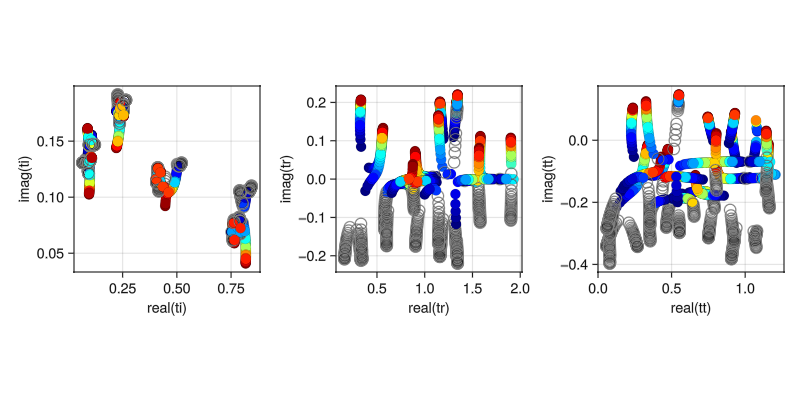

In [29]:
let
    b = beam_twob
    ionisationbursts = get_ionisationburst_limits(b, Ip, q_values)   
    TC = TCycle(b)

    data = test_data_all
    ### if you want to only look at one ionisationburst you can do this instead:
#     ib = 1 # e.g. first ionisationburst
#     data = filter(tup -> in(real(tup[1].ti/TC ), ionisationbursts[ib]... ), test_data_all)


    fig = Figure(size = (800,400))
    ax1 = Axis(fig[1, 1],  xlabel = "real(ti)", ylabel = "imag(ti)", aspect=1) 
    ax2 = Axis(fig[1, 2],  xlabel = "real(tr)", ylabel = "imag(tr)", aspect=1) 
    ax3 = Axis(fig[1, 3],  xlabel = "real(tt)", ylabel = "imag(tt)", aspect=1) 
    
    # ti in the complex plane
    [scatter!(ax1, [(real(tup[1].ti)/TC, imag(tup[1].ti)/TC)],
            color = tup[2] ? real(tup[1].q) : :transparent,
            markersize = 15, 
            strokecolor = tup[2] ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for tup in data]
    
    [scatter!(ax2, [reim(tup[1].tr)./TC],
            color = tup[2] ? real(tup[1].q) : :transparent,
            markersize = 15, 
            strokecolor = tup[2] ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for tup in data]
    
    [scatter!(ax3, [reim(tup[1].tr - tup[1].ti)./TC],
            color = tup[2] ? real(tup[1].q) : :transparent,
            markersize = 15, 
            strokecolor = tup[2] ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for tup in data]    
    
#     display(scr1, fig) # plot them onto an extra window 
    fig # plot here in the jupyter notebook
      
end

## getting classified saddles

In [43]:
### (calculating the relevance might take a while)
test_classified_saddles = get_classified_saddles(beam_twob, Ip, q_values, calculate_relevance=true)

┌ Warning: I'm hitting the integration plane more than once I think
└ @ Main ~/OneDrive/HHGsimPL.jl/src/header/PLIntegration2D/saddles-contributing.jl:45
┌ Warning: I'm hitting the integration plane more than once I think
└ @ Main ~/OneDrive/HHGsimPL.jl/src/header/PLIntegration2D/saddles-contributing.jl:45
┌ Warning: I'm hitting the integration plane more than once I think
└ @ Main ~/OneDrive/HHGsimPL.jl/src/header/PLIntegration2D/saddles-contributing.jl:45


1008-element Vector{ClassifiedSaddle}:
 ClassifiedSaddle(ti: 9.96 + 15.2im, tr: 36.85 + 9.31im, q11.0, 11, true)
 ClassifiedSaddle(ti: 10.16 + 15.08im, tr: 36.08 + 11.44im, q12.0, 11, true)
 ClassifiedSaddle(ti: 10.32 + 14.94im, tr: 35.78 + 12.86im, q13.0, 11, true)
 ClassifiedSaddle(ti: 10.44 + 14.79im, tr: 35.66 + 13.94im, q14.0, 11, true)
 ClassifiedSaddle(ti: 10.54 + 14.63im, tr: 35.61 + 14.79im, q15.0, 11, true)
 ClassifiedSaddle(ti: 10.61 + 14.48im, tr: 35.6 + 15.51im, q16.0, 11, true)
 ClassifiedSaddle(ti: 10.68 + 14.34im, tr: 35.61 + 16.11im, q17.0, 11, true)
 ClassifiedSaddle(ti: 10.73 + 14.19im, tr: 35.63 + 16.64im, q18.0, 11, true)
 ClassifiedSaddle(ti: 10.77 + 14.06im, tr: 35.67 + 17.11im, q19.0, 11, true)
 ClassifiedSaddle(ti: 10.8 + 13.92im, tr: 35.71 + 17.53im, q20.0, 11, true)
 ClassifiedSaddle(ti: 10.82 + 13.79im, tr: 35.75 + 17.91im, q21.0, 11, true)
 ClassifiedSaddle(ti: 10.84 + 13.67im, tr: 35.79 + 18.25im, q22.0, 11, true)
 ClassifiedSaddle(ti: 10.86 + 13.55im, tr:

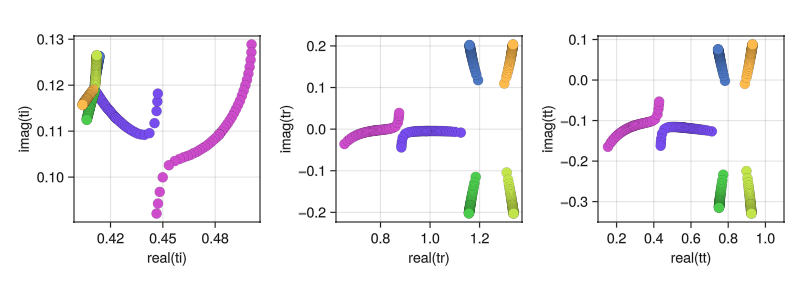

In [38]:
let
    b = beam_twob
    TC = TCycle(b)

    fig = Figure(size = (800, 300))
        
    ib = 3 # which ionisation burst
    data_cs = filter(cs -> div(cs.tag, 10) == ib , test_classified_saddles)
    
    ax1 = Axis(fig[1, 1],  xlabel = "real(ti)", ylabel = "imag(ti)", aspect=1) 
    ax2 = Axis(fig[1, 2],  xlabel = "real(tr)", ylabel = "imag(tr)", aspect=1) 
    ax3 = Axis(fig[1, 3],  xlabel = "real(tt)", ylabel = "imag(tt)", aspect=1) 

    ### colour according to tag or to harmonic order
#     color_cs(cs::ClassifiedSaddle) = cs.relevant ? real(cs.s.q) : :transparent
    color_cs(cs::ClassifiedSaddle) = tag_colours[cs.tag]

    # ionisation times
    [scatter!(ax1, [(real(cs.s.ti)/TC, imag(cs.s.ti)/TC)],
            color = color_cs(cs),
            markersize = 15, 
            strokecolor = cs.relevant ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for cs in data_cs]

    # recombination times
    [scatter!(ax2, [reim(cs.s.tr)./TC],
            color = color_cs(cs),
            markersize = 15, 
            strokecolor = cs.relevant ? :transparent : :grey,
            strokewidth = 2,
            colorrange = extrema(q_values), colormap = :jet) for cs in data_cs]

    # travel times
    [scatter!(ax3, [reim(cs.s.tr - cs.s.ti)./TC],
            color = color_cs(cs),
            markersize = 15, 
            strokecolor = cs.relevant ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for cs in data_cs]    
    
    xlims!(ax3, 0.1, 1.1)
    
    fig
#     display(scr1, fig)    
end

## calculate dipole for one given harmonic order

In [45]:
let
    q = 29.
    b = beam_twob

    S_f, S_grad, S_hessian = action_functions(b, Ip, q)
    
    function prefactor(ti,tr)
        ### eq. 5 from Emilio's thc paper
        ps = p_stationary(b, ti, tr)
        dip_r = dipole_SR_conj(ps .+ A(b)(tr), Ip)
        
        fontaine_SR_m0 = 1 / (kappa(Ip) * sqrt(2) * π)
        traveltime = tr - ti

        prefactor_const = (2*π/(im*traveltime))^(3/2) # spreading factor
        prefactor_const *= fontaine_SR_m0

        return prefactor_const * dip_r
    end

    ### find the respective saddles in the big data array of classified saddles
    saddles_q = filter(cs-> cs.s.q == q, test_classified_saddles)
    
    int_spm = zeros(ComplexF64,2) # sum over gaussian contributions
    
    for cs in saddles_q
        println("saddle: ", cs.s)
        @show cs.relevant
        if cs.relevant
            int_spm_s = saddles_gaussian_contribution(S_f, S_hessian, cs.s.ti, cs.s.tr, prefactor = prefactor)
            int_spm .+= int_spm_s
            
            @show int_spm_s
            println()
        end
    end
    @show int_spm
end

saddle: ti: 10.87 + 12.9im, tr: 36.07 + 20.05im, q29.0
cs.relevant = true
int_spm_s = ComplexF64[7.17254745679096e-13 + 1.7456032570287767e-13im, 0.0 + 0.0im]

saddle: ti: 7.77 + 14.45im, tr: 35.97 - 21.19im, q29.0
cs.relevant = false
saddle: ti: 10.1 + 17.12im, tr: 60.8 + 10.22im, q29.0
cs.relevant = true
int_spm_s = ComplexF64[2.1248476840755873e-8 + 8.760266717306502e-9im, 0.0 - 0.0im]

saddle: ti: 12.5 + 16.23im, tr: 64.74 - 10.17im, q29.0
cs.relevant = false
saddle: ti: 11.51 + 16.54im, tr: 90.49 - 1.59im, q29.0
cs.relevant = true
int_spm_s = ComplexF64[-3.592606219341964e-8 + 4.144175333837736e-7im, -0.0 + 0.0im]

saddle: ti: 10.63 + 14.61im, tr: 108.16 + 0.88im, q29.0
cs.relevant = true
int_spm_s = ComplexF64[-5.606692017344646e-6 + 1.2135838132459735e-6im, -0.0 + 0.0im]

saddle: ti: 25.77 + 17.31im, tr: 60.03 + 8.82im, q29.0
cs.relevant = true
int_spm_s = ComplexF64[6.25185584683384e-8 + 3.363531760225819e-8im, -0.0 + 0.0im]

saddle: ti: 25.3 + 20.41im, tr: 63.99 - 9.59im, q29.

2-element Vector{ComplexF64}:
 -0.00021695234522004072 + 0.0001819528577641286im
                     0.0 + 0.0im

## getting classified dipoles

In [44]:
test_classified_dipoles = get_classified_dipoles(beam_twob, Ip, q_values, test_classified_saddles)

1008-element Vector{ClassifiedDipole}:
 ClassifiedDipole(11.0, ComplexF64[-7.32127045009877e-5 + 7.596391633108878e-5im, -0.0 + 0.0im], 11, true, 1.0602392543879761e-16)
 ClassifiedDipole(11.0, ComplexF64[6.835296610268436e-5 + 0.00019167949360590826im, 0.0 + 0.0im], 12, false, 3.944781780005025e-16)
 ClassifiedDipole(11.0, ComplexF64[1.3390789374119684e-5 - 7.654883556440456e-5im, 0.0 + 0.0im], 13, true, 5.752443698217521e-17)
 ClassifiedDipole(11.0, ComplexF64[3.6744691561255263e-7 - 4.109894462743608e-8im, -0.0 + 0.0im], 14, true, 1.3021870421668041e-21)
 ClassifiedDipole(11.0, ComplexF64[7.73609859801325e-9 + 3.034183827568891e-7im, 0.0 + 0.0im], 15, true, 8.775071448714517e-22)
 ClassifiedDipole(11.0, ComplexF64[2.7025161304915313e-5 - 2.2584028403539204e-5im, 0.0 + 0.0im], 16, true, 1.1815323007514256e-17)
 ClassifiedDipole(11.0, ComplexF64[-6.6660049301109055e-6 + 4.027748109222876e-6im, 0.0 + 0.0im], 21, true, 5.777972034947356e-19)
 ClassifiedDipole(11.0, ComplexF64[-4.2932391

## plot the full spectrum

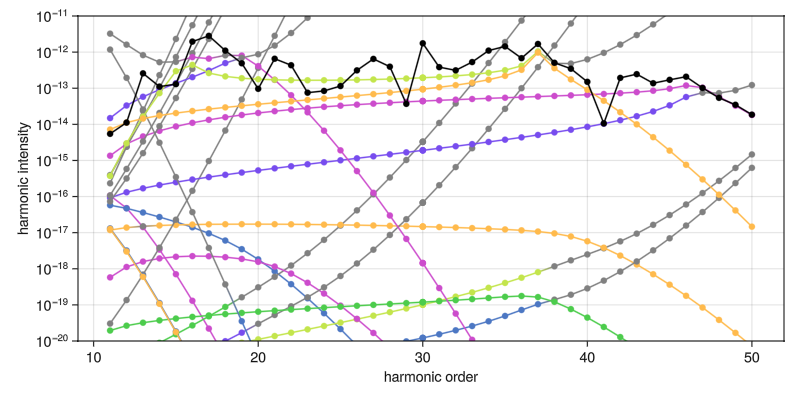

In [47]:
let
    beam = beam_twob
    data_dipoles = test_classified_dipoles
    
    
    f = Figure(size=(800,400))
    ax = Axis(f[1, 1], 
        yscale = log10, 
        xlabel = "harmonic order", ylabel = "harmonic intensity" ) 
    
    ### for each tag separately
    tags = unique([cd.tag for cd in data_dipoles])
    
    for tag in tags
        data_tag = sort(filter(cd -> cd.tag == tag, data_dipoles), by = cd -> cd.q)
        
        scatterlines!(ax, [(cd.q, cd.int) for cd in data_tag]
            , color = [cd.relevant ? tag_colors[tag] : :grey 
                for cd in data_tag] )
    end
    
    ### summing all the contributions from all the relevant dipoles (NOTE! coherent summation!)
    total_intensity = [
        harmonic_intensity(beam,
            ### dipole
            sum([cd.dip for cd in
            filter(cd-> cd.relevant && cd.q ==q, data_dipoles) # relevant dipoles for this q
            ]), q)
        for q in q_values
    ]
    
#     @show total_intensity
    scatterlines!(ax, q_values, total_intensity, color = :black)
    
    ylims!(ax, (1e-20,1e-11))

#     f[1,2] = Legend(f, ax)
    f
end

# consistent classification throughout an intensity scan

## Explanations

#### Problem:
Throughout an intensity scan, the naive classification via travel time doesn't work consistently s.t. at certain intensities the 'tag' of a saddle point would swap.

This demonstrates the problem. It's the fourth ionisation burst for $I_0 = 3e14$ and $I_0 = 4e14$ and we see that the first two trajectories change their tag.

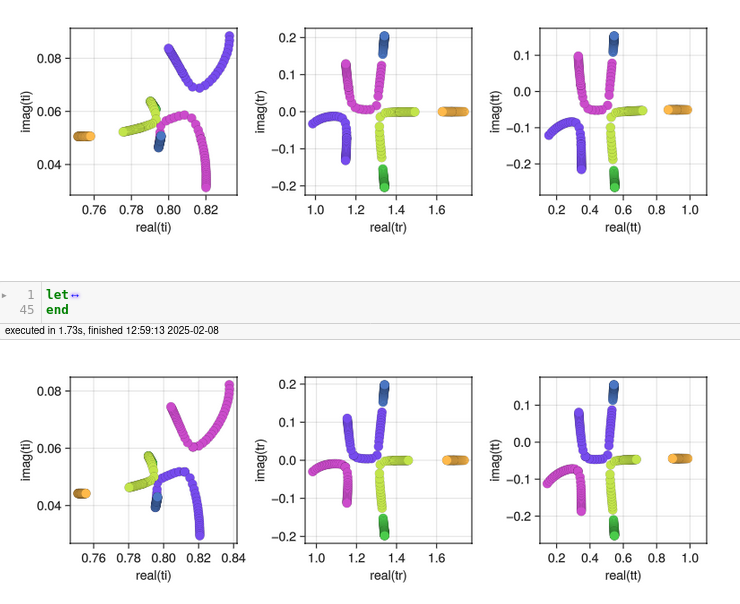

#### (one possible) Solution:
If we do an intensity scan (i.e, finding & classifying saddle points for beams with varying fundamental intensity) and we want to make sure the classification of saddle points remains consistens throughout the scan, we can do the following: First, we find & classify saddle points for, say, Intensity $I_{0,1}$, and then we use all those saddles as guesses for the next intensity $I_{0,2}$ and just infer the classification for each saddle point respectively. We can do this for a whole list (loop over) intensities $I_{0,i}$.

## test scenario

In [16]:
ib_lims = get_ionisationburst_limits(BeamBETC(Intensity1 = 2e14, Intensity2 = 2e14, lambda=λ, r=1, s=2, epsilon = 0., phi = π/2), Ip, q_values)

4-element Vector{Tuple{Float64, Float64}}:
 (-0.0494270430999999, 0.17195538731249999)
 (0.17195538731249999, 0.325967603775)
 (0.325967603775, 0.6310468192625001)
 (0.6310468192625001, 0.9505729569000001)

In [15]:
cs_1 = let
    I0 = 3e14
    beam = BeamBETC(Intensity1 = I0, Intensity2 = I0, lambda=λ, r=1, s=2, epsilon = 0., phi = π/2)
    get_classified_saddles(beam, Ip, q_values, calculate_relevance=false, ionisationbursts=ib_lims)
end

1008-element Vector{ClassifiedSaddle}:
 ClassifiedSaddle(ti: 11.34 + 13.12im, tr: 36.02 + 8.41im, q11.0, 11, true)
 ClassifiedSaddle(ti: 11.52 + 13.02im, tr: 35.4 + 10.31im, q12.0, 11, true)
 ClassifiedSaddle(ti: 11.66 + 12.89im, tr: 35.18 + 11.59im, q13.0, 11, true)
 ClassifiedSaddle(ti: 11.77 + 12.76im, tr: 35.09 + 12.55im, q14.0, 11, true)
 ClassifiedSaddle(ti: 11.86 + 12.63im, tr: 35.06 + 13.33im, q15.0, 11, true)
 ClassifiedSaddle(ti: 11.94 + 12.49im, tr: 35.07 + 13.97im, q16.0, 11, true)
 ClassifiedSaddle(ti: 12.0 + 12.36im, tr: 35.09 + 14.53im, q17.0, 11, true)
 ClassifiedSaddle(ti: 12.05 + 12.23im, tr: 35.13 + 15.01im, q18.0, 11, true)
 ClassifiedSaddle(ti: 12.09 + 12.11im, tr: 35.17 + 15.44im, q19.0, 11, true)
 ClassifiedSaddle(ti: 12.12 + 11.99im, tr: 35.21 + 15.82im, q20.0, 11, true)
 ClassifiedSaddle(ti: 12.15 + 11.87im, tr: 35.26 + 16.17im, q21.0, 11, true)
 ClassifiedSaddle(ti: 12.17 + 11.76im, tr: 35.31 + 16.48im, q22.0, 11, true)
 ClassifiedSaddle(ti: 12.18 + 11.65im, t

In [23]:
cs_2 = let
    I0 = 4e14
    beam = BeamBETC(Intensity1 = I0, Intensity2 = I0, lambda=λ, r=1, s=2, epsilon = 0., phi = π/2)
    get_classified_saddles(beam, Ip, q_values, calculate_relevance=false, ionisationbursts=ib_lims)
end

1008-element Vector{ClassifiedSaddle}:
 ClassifiedSaddle(ti: 11.92 + 12.34im, tr: 35.68 + 8.06im, q11.0, 11, true)
 ClassifiedSaddle(ti: 12.1 + 12.24im, tr: 35.12 + 9.87im, q12.0, 11, true)
 ClassifiedSaddle(ti: 12.23 + 12.13im, tr: 34.92 + 11.09im, q13.0, 11, true)
 ClassifiedSaddle(ti: 12.34 + 12.0im, tr: 34.84 + 12.02im, q14.0, 11, true)
 ClassifiedSaddle(ti: 12.43 + 11.87im, tr: 34.83 + 12.76im, q15.0, 11, true)
 ClassifiedSaddle(ti: 12.5 + 11.74im, tr: 34.84 + 13.38im, q16.0, 11, true)
 ClassifiedSaddle(ti: 12.56 + 11.62im, tr: 34.87 + 13.91im, q17.0, 11, true)
 ClassifiedSaddle(ti: 12.61 + 11.5im, tr: 34.91 + 14.37im, q18.0, 11, true)
 ClassifiedSaddle(ti: 12.65 + 11.38im, tr: 34.95 + 14.78im, q19.0, 11, true)
 ClassifiedSaddle(ti: 12.68 + 11.26im, tr: 35.0 + 15.15im, q20.0, 11, true)
 ClassifiedSaddle(ti: 12.71 + 11.15im, tr: 35.05 + 15.48im, q21.0, 11, true)
 ClassifiedSaddle(ti: 12.73 + 11.05im, tr: 35.09 + 15.79im, q22.0, 11, true)
 ClassifiedSaddle(ti: 12.75 + 10.94im, tr: 3

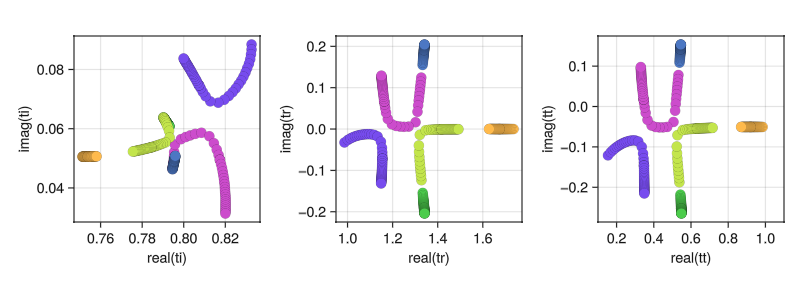

In [29]:
let
    TC = TCycle(lambda=λ)
    saddles = cs_1

    fig = Figure(size = (800, 300))
        
    ib = 4 # which ionisation burst
    data_cs = filter(cs -> div(cs.tag, 10) == ib , saddles)
    
    ax1 = Axis(fig[1, 1],  xlabel = "real(ti)", ylabel = "imag(ti)", aspect=1) 
    ax2 = Axis(fig[1, 2],  xlabel = "real(tr)", ylabel = "imag(tr)", aspect=1) 
    ax3 = Axis(fig[1, 3],  xlabel = "real(tt)", ylabel = "imag(tt)", aspect=1) 

    ### colour according to tag or to harmonic order
#     color_cs(cs::ClassifiedSaddle) = cs.relevant ? real(cs.s.q) : :transparent
    color_cs(cs::ClassifiedSaddle) = tag_colours[cs.tag]

    # ionisation times
    [scatter!(ax1, [(real(cs.s.ti)/TC, imag(cs.s.ti)/TC)],
            color = color_cs(cs),
            markersize = 15, 
            strokecolor = cs.relevant ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for cs in data_cs]

    # recombination times
    [scatter!(ax2, [reim(cs.s.tr)./TC],
            color = color_cs(cs),
            markersize = 15, 
            strokecolor = cs.relevant ? :transparent : :grey,
            strokewidth = 2,
            colorrange = extrema(q_values), colormap = :jet) for cs in data_cs]

    # travel times
    [scatter!(ax3, [reim(cs.s.tr - cs.s.ti)./TC],
            color = color_cs(cs),
            markersize = 15, 
            strokecolor = cs.relevant ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for cs in data_cs]    
    
    xlims!(ax3, 0.1, 1.1)
    
    fig
end

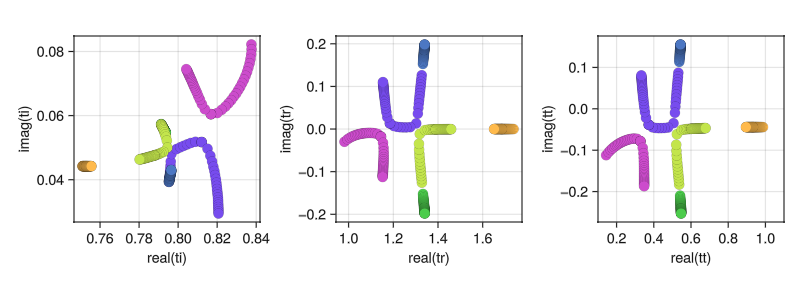

In [30]:
let
    TC = TCycle(lambda=λ)
    saddles = cs_2

    fig = Figure(size = (800, 300))
        
    ib = 4 # which ionisation burst
    data_cs = filter(cs -> div(cs.tag, 10) == ib , saddles)
    
    ax1 = Axis(fig[1, 1],  xlabel = "real(ti)", ylabel = "imag(ti)", aspect=1) 
    ax2 = Axis(fig[1, 2],  xlabel = "real(tr)", ylabel = "imag(tr)", aspect=1) 
    ax3 = Axis(fig[1, 3],  xlabel = "real(tt)", ylabel = "imag(tt)", aspect=1) 

    ### colour according to tag or to harmonic order
#     color_cs(cs::ClassifiedSaddle) = cs.relevant ? real(cs.s.q) : :transparent
    color_cs(cs::ClassifiedSaddle) = tag_colours[cs.tag]

    # ionisation times
    [scatter!(ax1, [(real(cs.s.ti)/TC, imag(cs.s.ti)/TC)],
            color = color_cs(cs),
            markersize = 15, 
            strokecolor = cs.relevant ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for cs in data_cs]

    # recombination times
    [scatter!(ax2, [reim(cs.s.tr)./TC],
            color = color_cs(cs),
            markersize = 15, 
            strokecolor = cs.relevant ? :transparent : :grey,
            strokewidth = 2,
            colorrange = extrema(q_values), colormap = :jet) for cs in data_cs]

    # travel times
    [scatter!(ax3, [reim(cs.s.tr - cs.s.ti)./TC],
            color = color_cs(cs),
            markersize = 15, 
            strokecolor = cs.relevant ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for cs in data_cs]    
    
    xlims!(ax3, 0.1, 1.1)
    
    fig
end

## new function: get_classified_saddles_similar()

In [39]:
function get_classified_saddles_similar(beam::Beam, Ip::Number, saddles_prev::Vector{ClassifiedSaddle};
        calculate_relevance::Bool=true
        )
    
    data_new = Vector{ClassifiedSaddle}()
    for cs in saddles_prev
        s_guess = cs.s # we find a new saddle point, taking the previous one as a guess

        s_new = find_saddle_similar_seed(s_guess.q, s_guess, b=beam, Ip=Ip)  
        if !isnothing(s_new)
            if calculate_relevance
                rel = check_contribution(action_functions(beam, Ip, cs.s.q)..., cs.s.ti, cs.s.tr)
                push!(data_new, ClassifiedSaddle(s_new, cs.tag, rel)) # we infer the tag from the tag of the previous classified saddle
            else
                push!(data_new, ClassifiedSaddle(s_new, cs.tag, true))
            end
        else
            println("We couldn't find a new saddle point taking $s_guess as a guess.")
        end
    end
    data_new
end

get_classified_saddles_similar (generic function with 1 method)

### testing it

In [36]:
cs_2_new = let
    I0 = 4e14
    beam = BeamBETC(Intensity1 = I0, Intensity2 = I0, lambda=λ, r=1, s=2, epsilon = 0., phi = π/2)
    get_classified_saddles_similar(beam, Ip, cs_1, calculate_relevance=false)
end

1008-element Vector{ClassifiedSaddle}:
 ClassifiedSaddle(ti: 11.92 + 12.34im, tr: 35.68 + 8.06im, q11.0, 11, true)
 ClassifiedSaddle(ti: 12.1 + 12.24im, tr: 35.12 + 9.87im, q12.0, 11, true)
 ClassifiedSaddle(ti: 12.23 + 12.13im, tr: 34.92 + 11.09im, q13.0, 11, true)
 ClassifiedSaddle(ti: 12.34 + 12.0im, tr: 34.84 + 12.02im, q14.0, 11, true)
 ClassifiedSaddle(ti: 12.43 + 11.87im, tr: 34.83 + 12.76im, q15.0, 11, true)
 ClassifiedSaddle(ti: 12.5 + 11.74im, tr: 34.84 + 13.38im, q16.0, 11, true)
 ClassifiedSaddle(ti: 12.56 + 11.62im, tr: 34.87 + 13.91im, q17.0, 11, true)
 ClassifiedSaddle(ti: 12.61 + 11.5im, tr: 34.91 + 14.37im, q18.0, 11, true)
 ClassifiedSaddle(ti: 12.65 + 11.38im, tr: 34.95 + 14.78im, q19.0, 11, true)
 ClassifiedSaddle(ti: 12.68 + 11.26im, tr: 35.0 + 15.15im, q20.0, 11, true)
 ClassifiedSaddle(ti: 12.71 + 11.15im, tr: 35.05 + 15.48im, q21.0, 11, true)
 ClassifiedSaddle(ti: 12.73 + 11.05im, tr: 35.09 + 15.79im, q22.0, 11, true)
 ClassifiedSaddle(ti: 12.75 + 10.94im, tr: 3

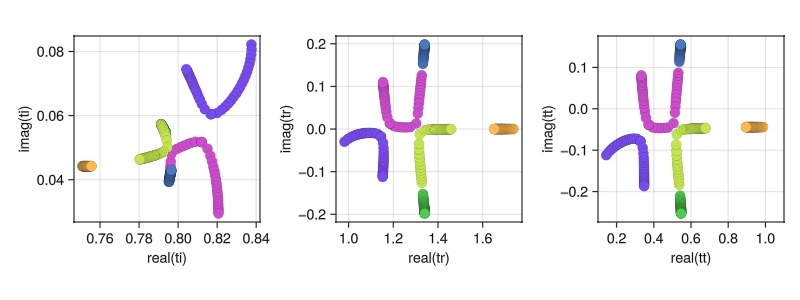

In [37]:
let
    TC = TCycle(lambda=λ)
    saddles = cs_2_new

    fig = Figure(size = (800, 300))
        
    ib = 4 # which ionisation burst
    data_cs = filter(cs -> div(cs.tag, 10) == ib , saddles)
    
    ax1 = Axis(fig[1, 1],  xlabel = "real(ti)", ylabel = "imag(ti)", aspect=1) 
    ax2 = Axis(fig[1, 2],  xlabel = "real(tr)", ylabel = "imag(tr)", aspect=1) 
    ax3 = Axis(fig[1, 3],  xlabel = "real(tt)", ylabel = "imag(tt)", aspect=1) 

    ### colour according to tag or to harmonic order
#     color_cs(cs::ClassifiedSaddle) = cs.relevant ? real(cs.s.q) : :transparent
    color_cs(cs::ClassifiedSaddle) = tag_colours[cs.tag]

    # ionisation times
    [scatter!(ax1, [(real(cs.s.ti)/TC, imag(cs.s.ti)/TC)],
            color = color_cs(cs),
            markersize = 15, 
            strokecolor = cs.relevant ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for cs in data_cs]

    # recombination times
    [scatter!(ax2, [reim(cs.s.tr)./TC],
            color = color_cs(cs),
            markersize = 15, 
            strokecolor = cs.relevant ? :transparent : :grey,
            strokewidth = 2,
            colorrange = extrema(q_values), colormap = :jet) for cs in data_cs]

    # travel times
    [scatter!(ax3, [reim(cs.s.tr - cs.s.ti)./TC],
            color = color_cs(cs),
            markersize = 15, 
            strokecolor = cs.relevant ? :transparent : :grey,
            strokewidth = 1,
            colorrange = extrema(q_values), colormap = :jet) for cs in data_cs]    
    
    xlims!(ax3, 0.1, 1.1)
    
    fig
end

# semi-classical electron trajectories

## get_trajectory()

In [19]:
struct Trajectory
    s::Saddle
    t1::Vector # part 1 of the contour ("inside the tunnel")
    x1::Vector
    t2::Vector # part 2 of the contour (in the continuum)
    x2::Vector
end

In [20]:
function get_trajectory(b::Beam, s::Saddle, Ntimes::Int64=20)
    pst = p_stationary(b, s.ti, s.tr)
    
    ### part 1: from Re(ti) + Im(ti)*im, all the way to Re(ti) + Im(tr)*im
    times_1 = collect(real(s.ti) .+ range(imag(s.ti), stop = imag(s.tr), length = Ntimes)*im)
    start_1 = times_1[1]
    traj_1 = [(pst*(t-s.ti) + integrated_vector_potential(b)(s.ti,t))[1] for t in times_1]
    
    ### part 2: from Re(ti) + Im(tr)*im, all the way to Re(tr) + Im(tr)*im
    times_2 = collect(range(real(s.ti), stop = real(s.tr), length = Ntimes) .+ imag(s.tr)*im)
    traj_2 = [(pst*(t-s.ti) + integrated_vector_potential(b)(s.ti,t))[1] for t in times_2]    
    
    return Trajectory(s, times_1, traj_1, times_2, traj_2)
    
end

get_trajectory (generic function with 2 methods)

In [26]:
test_classified_saddles = get_classified_saddles(beam_twob, Ip, q_values, calculate_relevance=false)

1008-element Vector{ClassifiedSaddle}:
 ClassifiedSaddle(ti: 9.96 + 15.2im, tr: 36.85 + 9.31im, q11.0, 11, true)
 ClassifiedSaddle(ti: 10.16 + 15.08im, tr: 36.08 + 11.44im, q12.0, 11, true)
 ClassifiedSaddle(ti: 10.32 + 14.94im, tr: 35.78 + 12.86im, q13.0, 11, true)
 ClassifiedSaddle(ti: 10.44 + 14.79im, tr: 35.66 + 13.94im, q14.0, 11, true)
 ClassifiedSaddle(ti: 10.54 + 14.63im, tr: 35.61 + 14.79im, q15.0, 11, true)
 ClassifiedSaddle(ti: 10.61 + 14.48im, tr: 35.6 + 15.51im, q16.0, 11, true)
 ClassifiedSaddle(ti: 10.68 + 14.34im, tr: 35.61 + 16.11im, q17.0, 11, true)
 ClassifiedSaddle(ti: 10.73 + 14.19im, tr: 35.63 + 16.64im, q18.0, 11, true)
 ClassifiedSaddle(ti: 10.77 + 14.06im, tr: 35.67 + 17.11im, q19.0, 11, true)
 ClassifiedSaddle(ti: 10.8 + 13.92im, tr: 35.71 + 17.53im, q20.0, 11, true)
 ClassifiedSaddle(ti: 10.82 + 13.79im, tr: 35.75 + 17.91im, q21.0, 11, true)
 ClassifiedSaddle(ti: 10.84 + 13.67im, tr: 35.79 + 18.25im, q22.0, 11, true)
 ClassifiedSaddle(ti: 10.86 + 13.55im, tr:

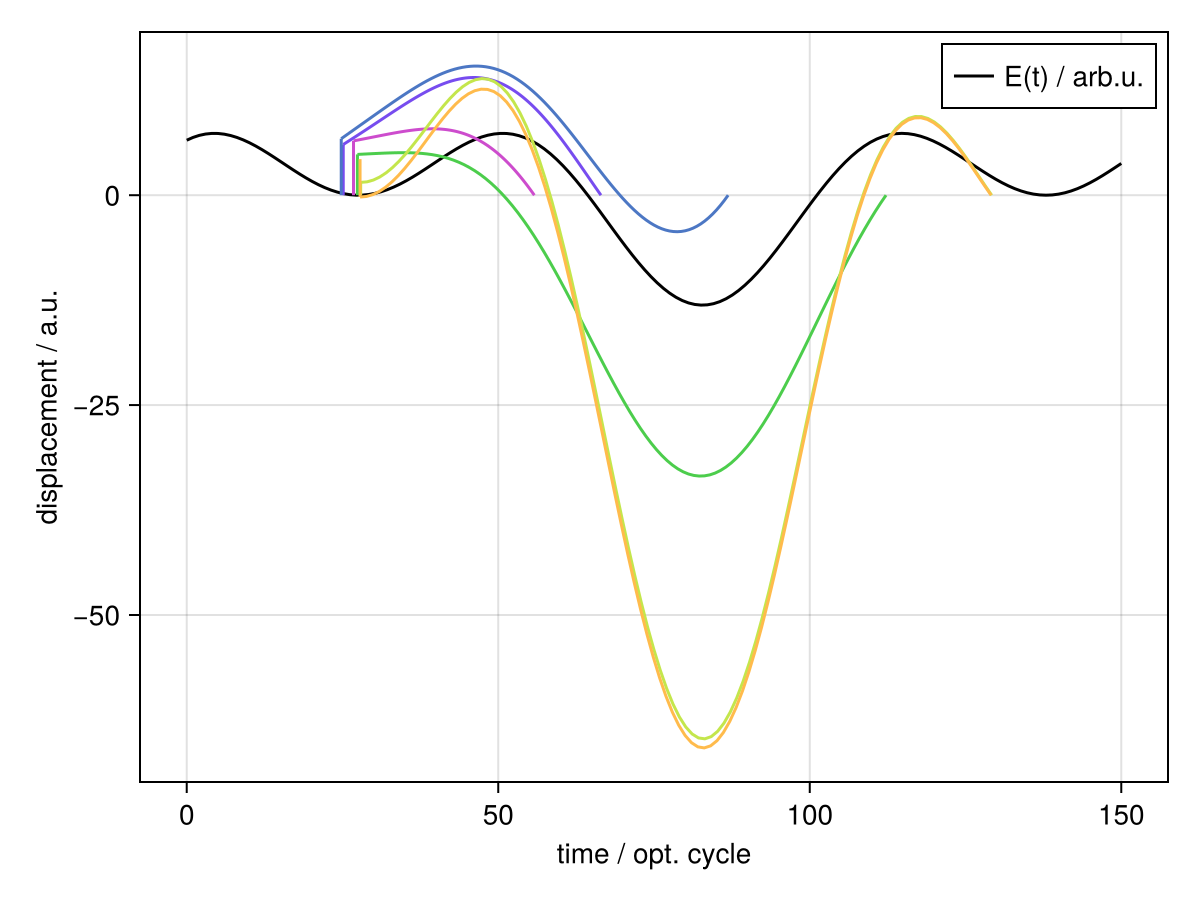

In [82]:
let 
    beam = beam_twob
    
    # filter the specific saddles you want (example here: only those for ionisation burst 2, i.e., within a range of ionisation times, and only one specific harmonic order)
    selected_saddles = filter(cs -> 20 < real(cs.s.ti) < 40 && cs.s.q == 20., test_classified_saddles)    
    
    TC = TCycle(beam) # 1 optical cycle = 2π/ω
    times = range(0, stop = 150, length = 150)
    
    efield = [E(beam)(t)[1] for t in times]
    
    f = Figure()
    ax = Axis(f[1, 1],  ylabel = "displacement / a.u.", xlabel = "time / opt. cycle")
        
    # adjust the factor *100 just so it looks nice 
    lines!(ax, times, efield.*100, label = "E(t) / arb.u.", color = :black) 
  
    for cs in selected_saddles
        traj = get_trajectory(beam, cs.s, 100)

        col = tag_colours[cs.tag] 
        lines!(ax, real.(traj.t1), real.(traj.x1), color = col, linestyle = :solid) # part 1 (the little vertical line)
        lines!(ax, real.(traj.t2), real.(traj.x2), color = col, linestyle = :solid) # part 2
    end

    axislegend(ax)
    f
end

In [36]:
using CairoMakie